#Description:

The project is about on world's largest taxi company, Uber inc. In this project, we're looking to predict the fare for their future transactional cases. Uber delivers service to lakhs of customers daily. Now it becomes significant to manage their data properly to come up with new business ideas to get the best results. Eventually, it becomes essential to estimate the fare prices accurately.

The dataset contains the following fields:
* key - a unique identifier for each trip
* fare_amount - the cost of each trip in usd
* pickup_datetime - date and time when the meter was engaged
* passenger_count - the number of passengers in the vehicle (driver entered value)
* pickup_longitude - the longitude where the meter was engaged
* pickup_latitude - the latitude where the meter was engaged
* dropoff_longitude - the longitude where the meter was disengaged
* dropoff_latitude - the latitude where the meter was disengaged

Acknowledgment:
The dataset is referred from Kaggle.

Objective:
- Understand the Dataset & clean it up (if required).
- Build Regression models to predict the fare price of uber ride.
- Also evaluate the models & compare thier respective scores like R2, RMSE, etc.

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('uber.csv')

#Data Prepration

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [4]:
df.shape

(62527, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62527 entries, 0 to 62526
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         62527 non-null  int64  
 1   key                62527 non-null  object 
 2   fare_amount        62527 non-null  float64
 3   pickup_datetime    62527 non-null  object 
 4   pickup_longitude   62527 non-null  float64
 5   pickup_latitude    62526 non-null  float64
 6   dropoff_longitude  62526 non-null  float64
 7   dropoff_latitude   62526 non-null  float64
 8   passenger_count    62526 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 4.3+ MB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,1
dropoff_longitude,1
dropoff_latitude,1
passenger_count,1


In [7]:
df.dropna(inplace = True)

In [8]:
df.isnull().sum()


,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,6.252600e+04,62526.000000,62526.000000,62526.000000,62526.000000,62526.000000,62526.000000
mean,2.769606e+07,11.429263,-72.538919,39.937683,-72.550323,39.934674,1.676758
std,1.602635e+07,10.036980,11.073857,6.472558,10.663850,6.111677,1.296592
min,4.800000e+01,0.000000,-748.016667,-74.015515,-737.916665,-74.008745,0.000000
25%,1.380723e+07,6.000000,-73.992086,40.734735,-73.991462,40.733614,1.000000
50%,2.766978e+07,8.500000,-73.981830,40.752493,-73.980125,40.752943,1.000000
75%,4.149748e+07,12.700000,-73.967173,40.767116,-73.963706,40.768170,2.000000
max,5.542169e+07,350.000000,40.808425,404.433332,40.828377,45.031598,6.000000


## EDA

### Univariate Analysis

<Axes: xlabel='fare_amount', ylabel='Count'>

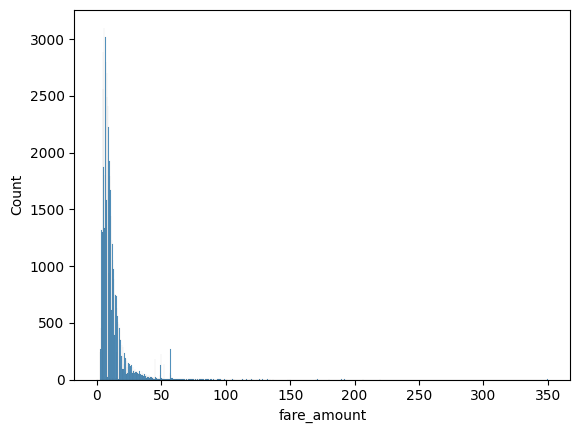

In [11]:
sns.histplot(df['fare_amount'])

<Axes: ylabel='fare_amount'>

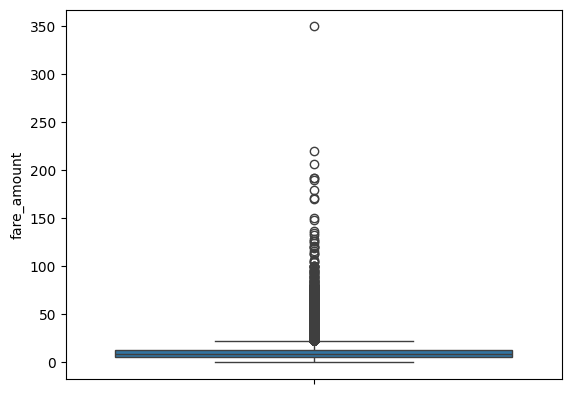

In [12]:
sns.boxplot(df['fare_amount'])

### Fare columns have more outliers to using IQR we handle the outliers. Fare amount never in negative and most of outlire are above than 200.



In [13]:
df = df[df['fare_amount'] > 0]

In [14]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)

In [15]:
IQR = Q3 - Q1

In [16]:
lower_bound = Q1 - 1.5* IQR
upper_bound = Q3 + 1.5* IQR

In [17]:
df = df[(df['fare_amount'] >= lower_bound ) & (df['fare_amount'] <= upper_bound)]

<Axes: ylabel='fare_amount'>

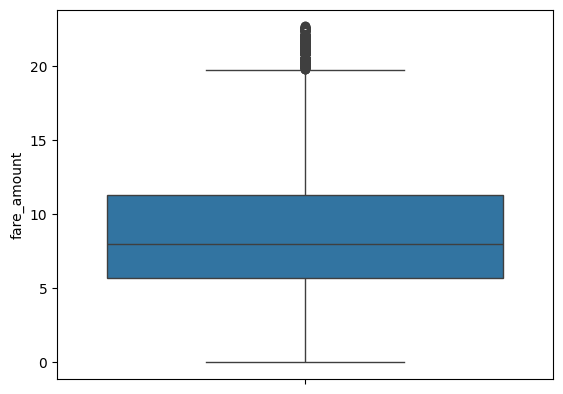

In [18]:
sns.boxplot(df['fare_amount'])



 -- Most fares are between ₹5 to ₹11

 -- Median (middle line) ≈ ₹8

 -- there are outlier but its acceptable



<Axes: xlabel='fare_amount', ylabel='Density'>

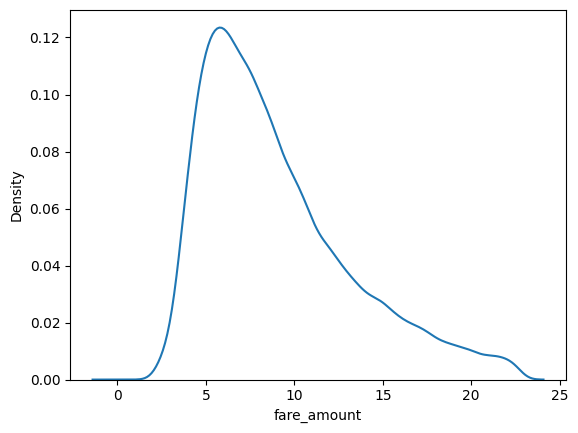

In [19]:
sns.kdeplot(df.fare_amount)

In [20]:
df['passenger_count'].value_counts()

,count
passenger_count,
1.0,39751
2.0,8378
5.0,4017
3.0,2577
4.0,1206
6.0,1134
0.0,211


In [21]:
df = df [(df['passenger_count'] >= 1 ) & (df['passenger_count'] <= 6)]

<Axes: ylabel='passenger_count'>

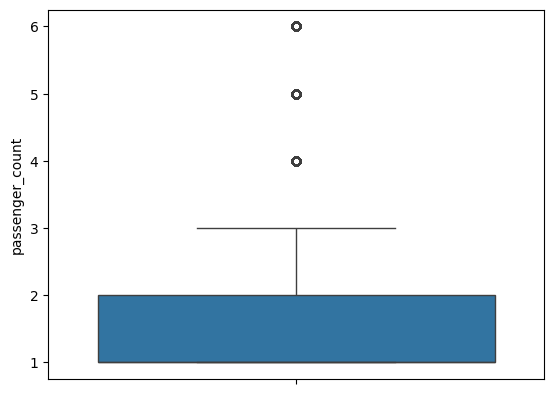

In [22]:
sns.boxplot(df['passenger_count'])

###The data is highly skewed toward single-passenger rides, while higher passenger counts are less frequent but valid.

## Bivariate Analysis

<Axes: xlabel='pickup_latitude', ylabel='dropoff_latitude'>

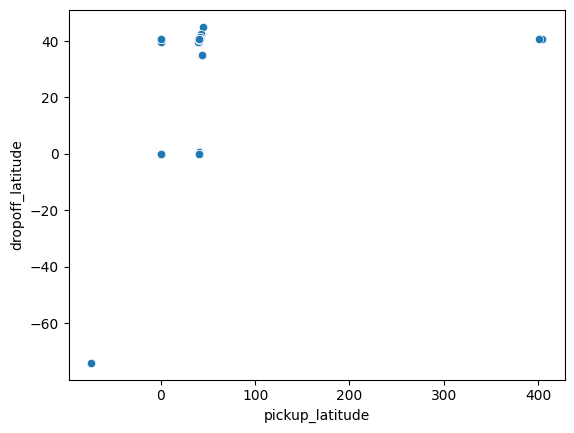

In [23]:
sns.scatterplot(x = df['pickup_latitude'], y = df['dropoff_latitude'])

<Axes: xlabel='pickup_longitude', ylabel='dropoff_longitude'>

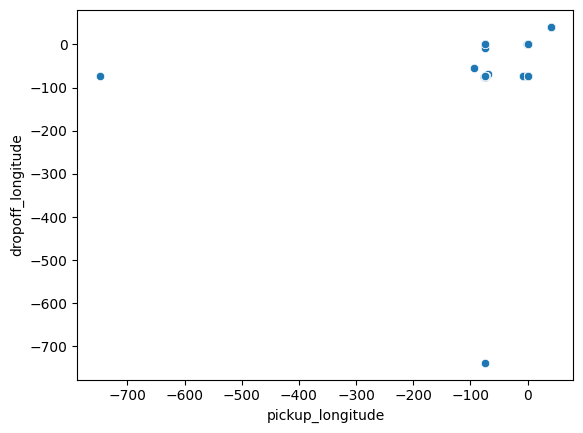

In [24]:
sns.scatterplot(x = df['pickup_longitude'], y = df['dropoff_longitude'])

<Axes: xlabel='pickup_latitude', ylabel='pickup_longitude'>

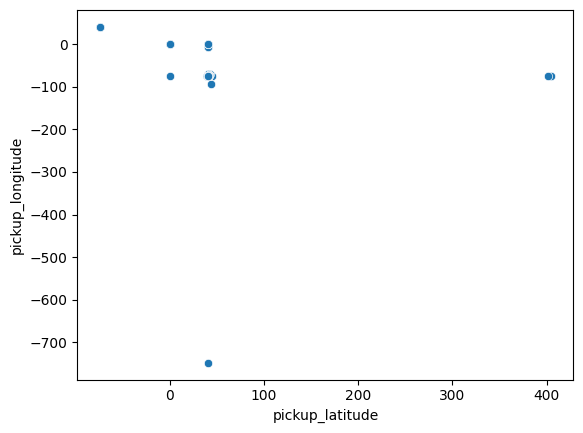

In [25]:
sns.scatterplot(x = df['pickup_latitude'], y = df['pickup_longitude'])

In [26]:
df = df[
    (df['pickup_latitude'].between(40, 42)) &
    (df['pickup_longitude'].between(-75, -72))
]

<Axes: xlabel='pickup_latitude', ylabel='pickup_longitude'>

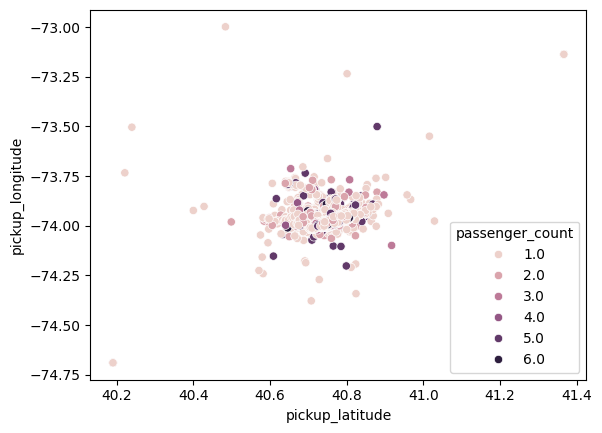

In [27]:
sns.scatterplot(x = df['pickup_latitude'], y = df['pickup_longitude'], hue = df['passenger_count'])

In [28]:
df = df [(df['dropoff_latitude'].between(40,42)) & (df['dropoff_longitude'].between(-75,-72))]

<Axes: xlabel='dropoff_latitude', ylabel='dropoff_longitude'>

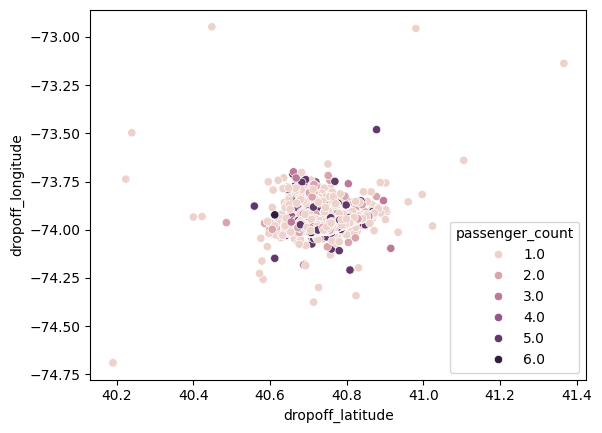

In [29]:
sns.scatterplot(x = df['dropoff_latitude'], y = df['dropoff_longitude'], hue = df['passenger_count'], color = 'red')

### Multivariate analysis

In [30]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,5.592000e+04,55920.000000,55920.000000,55920.000000,55920.000000,55920.000000,55920.000000
mean,2.768257e+07,9.011861,-73.979573,40.752104,-73.977918,40.752366,1.680991
std,1.602181e+07,4.219226,0.029336,0.027651,0.029965,0.029879,1.294314
min,4.800000e+01,0.010000,-74.689831,40.190564,-74.689831,40.190564,1.000000
25%,1.379325e+07,5.700000,-73.992648,40.737003,-73.991911,40.736817,1.000000
50%,2.765190e+07,8.000000,-73.982528,40.753063,-73.981270,40.753798,1.000000
75%,4.145744e+07,11.300000,-73.970323,40.766813,-73.967895,40.768026,2.000000
max,5.542169e+07,22.670000,-72.998792,41.366138,-72.947718,41.366138,6.000000


In [31]:
df = df.drop(columns=['Unnamed: 0'])

In [32]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [33]:
dt = pd.to_datetime(df['pickup_datetime'])

In [34]:
df['year'] = dt.dt.year
df['month'] = dt.dt.month
df['day'] = dt.dt.day
df['weekday'] = dt.dt.weekday
df['hour'] = dt.dt.hour

In [35]:
df.drop(columns=['pickup_datetime','key'],inplace=True)

In [36]:
df.corr()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,weekday,hour
fare_amount,1.000000,0.003635,-0.079798,0.078936,-0.087103,0.016213,0.138620,0.026503,0.011534,0.019195,-0.009164
pickup_longitude,0.003635,1.000000,0.513220,0.725288,0.339987,-0.007887,-0.020165,0.004698,-0.007777,-0.014155,-0.003600
pickup_latitude,-0.079798,0.513220,1.000000,0.336190,0.651945,-0.006216,-0.006827,-0.001698,-0.002490,-0.047606,0.036348
dropoff_longitude,0.078936,0.725288,0.336190,1.000000,0.481120,-0.006884,-0.018004,0.001894,-0.006493,-0.001216,-0.030730
dropoff_latitude,-0.087103,0.339987,0.651945,0.481120,1.000000,-0.003577,-0.003811,-0.000496,-0.000680,-0.035021,0.027655
passenger_count,0.016213,-0.007887,-0.006216,-0.006884,-0.003577,1.000000,-0.002219,0.011193,0.002699,0.033404,0.017632
year,0.138620,-0.020165,-0.006827,-0.018004,-0.003811,-0.002219,1.000000,-0.118951,-0.011754,0.000130,0.003017
month,0.026503,0.004698,-0.001698,0.001894,-0.000496,0.011193,-0.118951,1.000000,-0.013381,-0.006836,-0.007749
day,0.011534,-0.007777,-0.002490,-0.006493,-0.000680,0.002699,-0.011754,-0.013381,1.000000,0.003476,0.008422
weekday,0.019195,-0.014155,-0.047606,-0.001216,-0.035021,0.033404,0.000130,-0.006836,0.003476,1.000000,-0.094315


<Axes: >

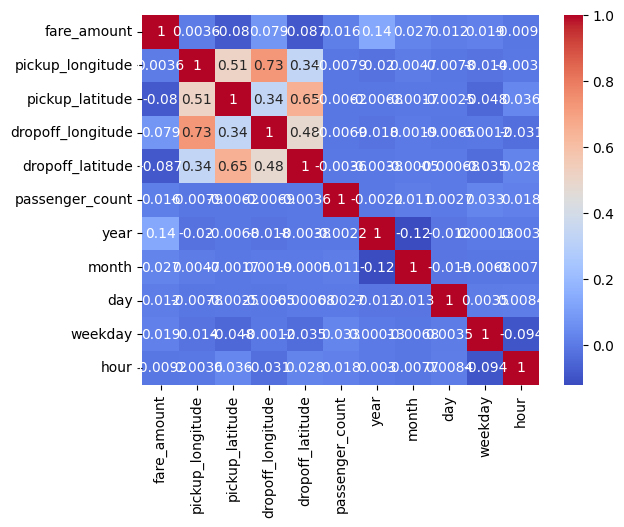

In [37]:
sns.heatmap(df.corr(),annot = True,cmap = 'coolwarm')

## Creating new feature distance_km ,

In [38]:
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)

In [39]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

In [40]:
df = df.drop(columns=[
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude'
])

<Axes: ylabel='distance_km'>

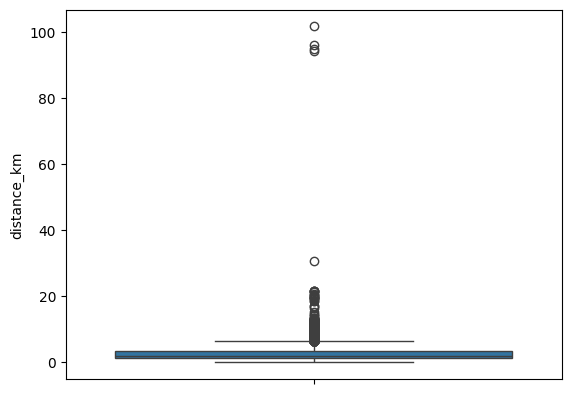

In [41]:
sns.boxplot(df['distance_km'])

In [42]:
(df['distance_km'] > 30).sum()

np.int64(5)

In [43]:
df['distance_km'].shape

(55920,)

In [44]:
df = df[(df['distance_km'] > 0) & (df['distance_km'] <= 30)]

In [45]:
df['distance_km'].quantile([0.90, 0.95, 0.99])

,distance_km
0.90,5.172482
0.95,6.361491
0.99,8.650202


In [46]:
Q1 = df['distance_km'].quantile(0.25)
Q3 = df['distance_km'].quantile(0.75)

In [47]:
IQR = Q3 - Q1
IQR

np.float64(2.128252168013371)

In [48]:
lower_bound = Q1 - 1.5* IQR
upper_bound = Q3 + 1.5* IQR

In [49]:
df = df[(df['distance_km'] >= lower_bound ) & (df['distance_km'] <= upper_bound)]

<Axes: ylabel='distance_km'>

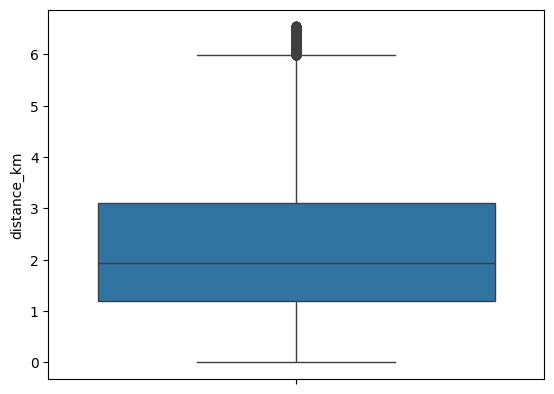

In [50]:
sns.boxplot(df['distance_km'])

In [51]:
(df['distance_km'] < 0.1 ).sum()

np.int64(281)

### 931 rows are greater than 0.1 which is approx 0.55 % data so we can remove it.

In [52]:
df = df[df['distance_km'] > 0.1]

<Axes: xlabel='distance_km', ylabel='Density'>

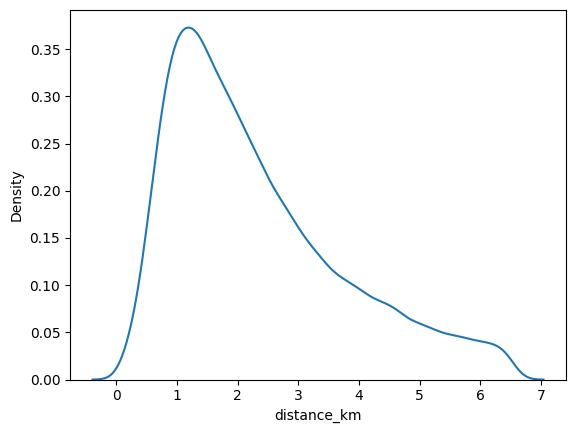

In [53]:
sns.kdeplot(df['distance_km'])

In [54]:
(df['distance_km'] ).describe()

,distance_km
count,52618.000000
mean,2.319305
std,1.440209
min,0.100227
25%,1.205472
50%,1.950094
75%,3.121230
max,6.548852


In [55]:
#df['fare_per_km'] = df['fare_amount'] / df['distance_km']

###Distance is right-skewed with most rides between 1–3 km and a median around 2 km. A few mild outliers exist but are valid and do not require removal.

<Axes: xlabel='distance_km', ylabel='fare_amount'>

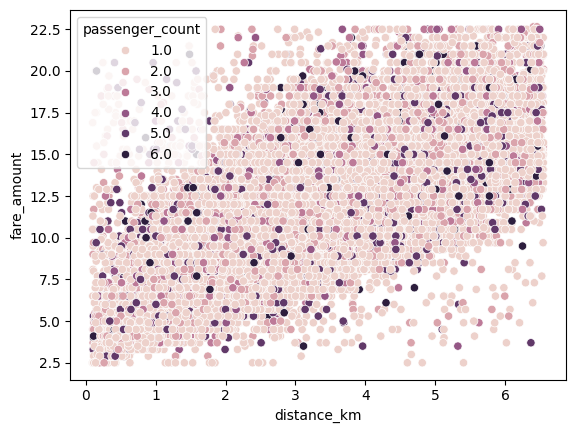

In [56]:
sns.scatterplot(y = df['fare_amount'], x= df['distance_km'], hue = df['passenger_count'])

###

### The scatter plot shows a strong positive relationship between distance and fare. However, passenger count does not significantly affect fare, as the data points overlap across different passenger values.

<Axes: >

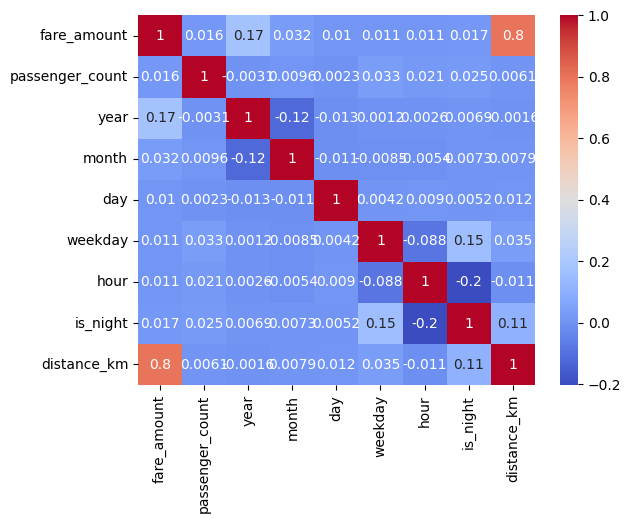

In [57]:
sns.heatmap(df.corr(),annot = True,cmap = 'coolwarm')

## Split data

In [58]:
df.head()

,fare_amount,passenger_count,year,month,day,weekday,hour,is_night,distance_km
0,7.5,1.0,2015,5,7,3,19,0,1.683323
1,7.7,1.0,2009,7,17,4,20,0,2.457590
2,12.9,1.0,2009,8,24,0,21,0,5.036377
3,5.3,3.0,2009,6,26,4,8,0,1.661683
4,16.0,5.0,2014,8,28,3,17,0,4.475450


In [59]:
x = df.drop(columns = ['fare_amount'])
y = df['fare_amount']

In [60]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [61]:
xtrain.shape

(42094, 8)

In [62]:
ytrain.shape

(42094,)

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [64]:
xtrain_scaled = xtrain.copy()
xtest_scaled = xtest.copy()

In [65]:
xtrain_scaled[['distance_km']] = scaler.fit_transform(xtrain[['distance_km']])
xtest_scaled[['distance_km']] = scaler.transform(xtest[['distance_km']])

## Feature selection

In [66]:
lr  = LinearRegression()

In [67]:
rfe = RFE(estimator=lr,n_features_to_select = 5)

In [68]:
rfe = rfe.fit(xtrain_scaled,ytrain)

In [69]:
rfe.support_

array([ True,  True,  True, False, False, False,  True,  True])

In [70]:
rfe.ranking_

array([1, 1, 1, 4, 2, 3, 1, 1])

In [71]:
col = xtrain_scaled.columns[rfe.support_]
col

Index(['passenger_count', 'year', 'month', 'is_night', 'distance_km'], dtype='object')

## OLS -- for analysis

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
x_train_rfe = sm.add_constant(xtrain_scaled[col])
model = sm.OLS(ytrain,x_train_rfe).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                 1.773e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:57:26   Log-Likelihood:                -91816.
No. Observations:               42094   AIC:                         1.836e+05
Df Residuals:                   42088   BIC:                         1.837e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -731.6115     11.327    -

# Model Evaluation

In [73]:
ytrain_pred = model.predict(x_train_rfe)

In [74]:
error = ytrain - ytrain_pred

<Axes: ylabel='Density'>

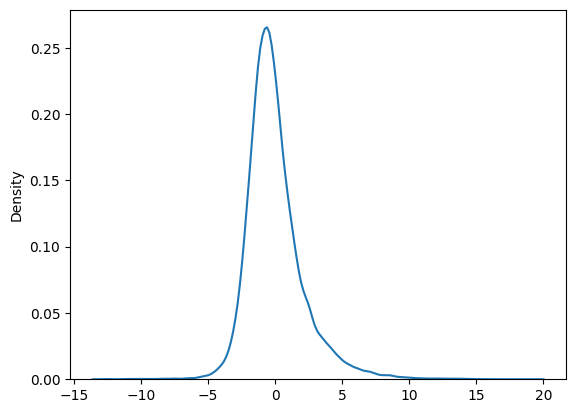

In [75]:
sns.kdeplot(error)

In [76]:
y_train_pred=model.predict(x_train_rfe)

In [77]:
r2 = r2_score(ytrain,y_train_pred)
r2

0.6780941540721863

60- 70% predicted values are correct.

In [78]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score, root_mean_squared_error

## predicting for testing data

In [79]:
x_test_rfe = sm.add_constant(xtest_scaled[col])
y_test_pred = model.predict(x_test_rfe)
r2 = r2_score(ytest, y_test_pred)

In [80]:
r2

0.6763052372618084

# Model training

In [81]:
x_train_rfe

,const,passenger_count,year,month,is_night,distance_km
47827,1.0,1.0,2010,7,0,-0.954438
21774,1.0,1.0,2015,6,0,-1.190248
10186,1.0,3.0,2011,4,0,1.188611
40688,1.0,1.0,2009,4,0,-0.983196
18413,1.0,1.0,2011,1,0,-0.939557
...,...,...,...,...,...,...
13382,1.0,6.0,2011,8,1,-1.281569
53180,1.0,1.0,2011,12,0,-0.699239
45280,1.0,1.0,2010,12,0,-1.212038
1014,1.0,1.0,2009,12,0,0.353922


In [82]:
final_model = LinearRegression()
final_model = lr.fit(xtrain_scaled[col],ytrain)

In [83]:
final_model.coef_

array([ 0.03419397,  0.36785129,  0.05223586, -0.66244498,  3.05088093])

## prediction

In [84]:
y_test_pred = final_model.predict(xtest_scaled[col])

In [85]:
y_test_pred

array([12.45897893, 11.85215855,  7.18083848, ...,  7.29671938,
        6.72884324, 16.95755942])

In [86]:
r2 = r2_score(ytest,y_test_pred)

In [87]:
r2

0.6763052372618061

In [88]:
n=xtest_scaled.shape[0]
p=xtest_scaled.shape[1]

In [89]:

adj_r2=(1-(1-r2)*(n-1)/(n-p-1))
adj_r2

0.676058964498905

In [90]:
mean_squared_error(ytest,y_test_pred)

4.586776984548328

In [91]:
rmse = np.sqrt(mean_squared_error(ytest,y_test_pred))
rmse

np.float64(2.1416762090821124)

In [92]:
mean_absolute_error(ytest,y_test_pred)

1.5196503270893833

## Actual vs Predicted graph

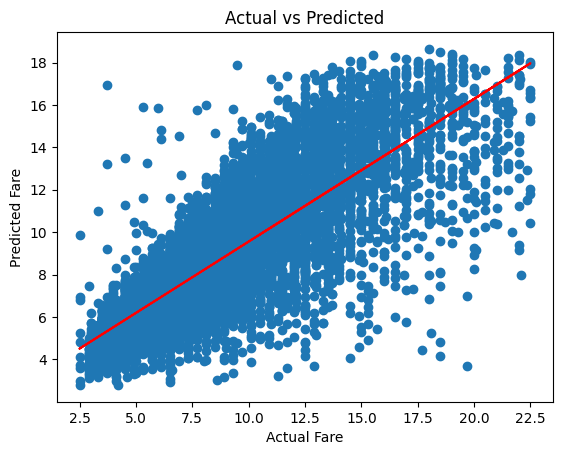

In [93]:
import matplotlib.pyplot as plt

plt.scatter(ytest, y_test_pred)

# best fit line
m,b = np.polyfit(ytest, y_test_pred, 1)
plt.plot(ytest, m*ytest + b, color='red')
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted")
plt.show()

## Residual Plot

In [94]:
residuals = ytest - y_test_pred

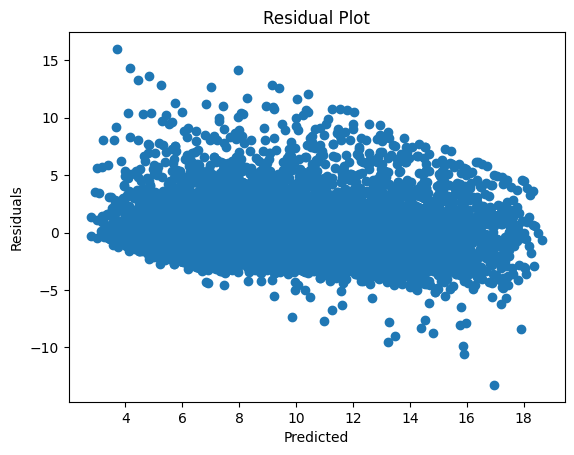

In [95]:
plt.scatter(y_test_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

<Axes: xlabel='fare_amount', ylabel='Density'>

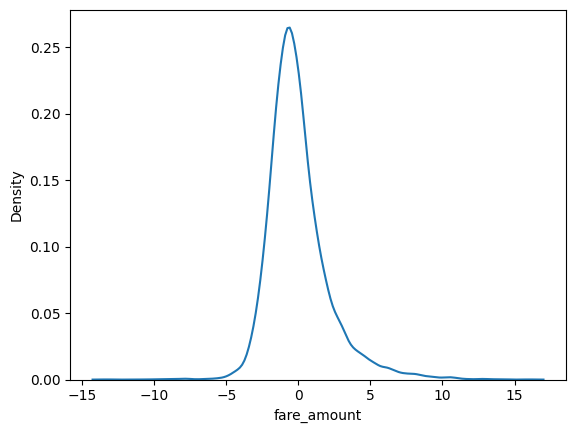

In [96]:
sns.kdeplot(residuals)

## New Data Testing

In [110]:
new_data = {
    'year': 2012,
    'month': 5,
    'day': 10,
    'weekday': 3,
    'hour': 14,
    'distance_km': 30,
    'passenger_count': 2
}

In [111]:
new_df = pd.DataFrame([new_data])

In [112]:
new_df['is_night'] = new_df['hour'].apply(lambda x: 1 if x>= 22 or x<= 5 else 0)

In [113]:
new_df[['distance_km']] = scaler.transform(new_df[['distance_km']])

In [114]:
new_df = new_df[col]

In [115]:
new_df = sm.add_constant(new_df, has_constant='add')

In [116]:
Prediction = model.predict(new_df)

In [117]:
print("Predicted Fare:", Prediction[0])

Predicted Fare: 67.3449649306661


In [118]:
import pickle

### save the model

In [3]:
with open('uber_auto.pkl', 'wb') as f:
  pickle.dump(model,f)

NameError: name 'pickle' is not defined

### Load the model

In [120]:
with open('uber_auto.pkl', 'rb') as f:
  LRmodel = pickle.load(f)

In [121]:
R2 = r2_score(ytest, y_test_pred)

In [122]:
R2

0.6763052372618061

In [2]:
import os
os.listdir()

['.ipynb_checkpoints', 'uber.csv', 'Uber.ipynb']